# fed papers experiment using SVC with linear kernel

# 1 - Imports and Path

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lexos.dtm import DTM, Vectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from lexos.classification import trainer
import lexos.corpus.corpus_stats as cs
from sklearn.model_selection import train_test_split

BASE = Path.cwd() # gets cwd, run this notebook from doc_src/docs/tutorials/classification
DATA = BASE / "fed_papers"

print("Base:", BASE)
print("Data dir exists:", DATA.exists())

Base: c:\Users\gabal\LocalFiles\Lexos_Independant_Research\lexos\doc_src\docs\tutorials\classification
Data dir exists: True


## 2) Collect train and test files

In [3]:
train_dirs = ["HAMILTON", "MADISON"]
test_dirs = ["COAUTHORED", "DISPUTED"]

train_files = []
for d in train_dirs:
    train_files.extend(sorted((DATA / d).glob("*.txt")))

test_files = []
for d in test_dirs:
    test_files.extend(sorted((DATA / d).glob("*.txt")))

print("Train files:", len(train_files), "Test files:", len(test_files))
assert train_files and test_files, "No files found; check working directory and folder structure."

Train files: 65 Test files: 15


## 2.1 Sort files by filename

In [4]:
train_files = sorted(train_files, key=lambda x: x.name)
test_files = sorted(test_files, key=lambda x: x.name)

## 3) Scrubber + Tokenizer

In [5]:
from lexos.scrubber.scrubber import Scrubber
from lexos.tokenizer import Tokenizer

scrubber = Scrubber()
scrubber.add_pipe("lower_case")
scrubber.add_pipe("digits")
scrubber.add_pipe("punctuation")

tokenizer = Tokenizer(model="en_core_web_sm")  # or any installed model

# 4) Addressing Concerns
In this section, we will:
1. Normalize features only if the Document-Term Matrix (DTM) is not already normalized.
2. Split the data into training and testing sets before fitting the vectorizer to avoid data leakage.

In [6]:
# Step 1: Load and preprocess the data

# Split the data into training and testing sets
train_labels = ["Hamilton"] * len(train_files)  # One label per training file
test_labels = ["Coauthored"] * len(test_files[:len(test_files)//2]) + ["Disputed"] * len(test_files[len(test_files)//2:])  # One label per test file

# Combine files and labels
data_files = train_files + test_files
labels = train_labels + test_labels

# Ensure the lengths of data_files and labels match
assert len(data_files) == len(labels), f"Mismatch between data_files ({len(data_files)}) and labels ({len(labels)})"

# Split the data
train_data, test_data, train_labels, test_labels = train_test_split(
    data_files, labels, test_size=0.3, random_state=42, stratify=labels
)

# Preprocess the data: read and tokenize
train_docs = [tokenizer(scrubber.scrub(file.read_text())) for file in train_data]
test_docs = [tokenizer(scrubber.scrub(file.read_text())) for file in test_data]


In [7]:
# Initialize the DTM
dtm = DTM()

# Fit the DTM on the training data and transform it
train_dtm = dtm.fit_transform(train_docs, train_labels)

# Transform the test data
test_dtm = dtm.vectorizer.transform(test_docs)

# Check if the DTM is already normalized
if not dtm.vectorizer.norm:
    scaler = StandardScaler(with_mean=False)  # Disable centering for sparse matrices
    train_dtm = scaler.fit_transform(train_dtm)  # Fit only on training data
    test_dtm = scaler.transform(test_dtm)  # Transform test data

In [10]:
# Step 2: Train the classifier
from lexos.classification.trainer import fit_classifier
from sklearn.metrics import classification_report

# Train the classifier using the preprocessed data
classifier = fit_classifier(
    feature_matrix=train_dtm,
    target_labels=train_labels,
    model="svc",  # Support Vector Classifier
    normalize=None,  # Normalization already handled above
    kernel="linear"  # Explicitly set the kernel to linear
)

# Evaluate the classifier on the test set
predictions = classifier.predict(test_dtm)
report = classification_report(test_labels, predictions)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

  Coauthored       0.00      0.00      0.00         2
    Disputed       0.00      0.00      0.00         2
    Hamilton       0.83      1.00      0.91        20

    accuracy                           0.83        24
   macro avg       0.28      0.33      0.30        24
weighted avg       0.69      0.83      0.76        24



c:\Users\gabal\LocalFiles\Lexos_Independant_Research\lexos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gabal\LocalFiles\Lexos_Independant_Research\lexos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gabal\LocalFiles\Lexos_Independant_Research\lexos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

# Checking feature importance (only feasible for linear kernel)

Top 10 Features by Importance:
Feature 'representatives': Importance -0.0023896316488401714
Feature 'abuses': Importance 0.002356310800979184
Feature 'test': Importance 0.002356310800979184
Feature 'representative': Importance -0.0023477764969753656
Feature 'pursuit': Importance 0.0020601529698840316
Feature 'reviewed': Importance 0.002040298402325268
Feature 'contriving': Importance 0.002031937605638354
Feature 'sentinel': Importance 0.002031937605638354
Feature 'secures': Importance 0.002031937605638354
Feature 'rigorously': Importance 0.002031937605638354


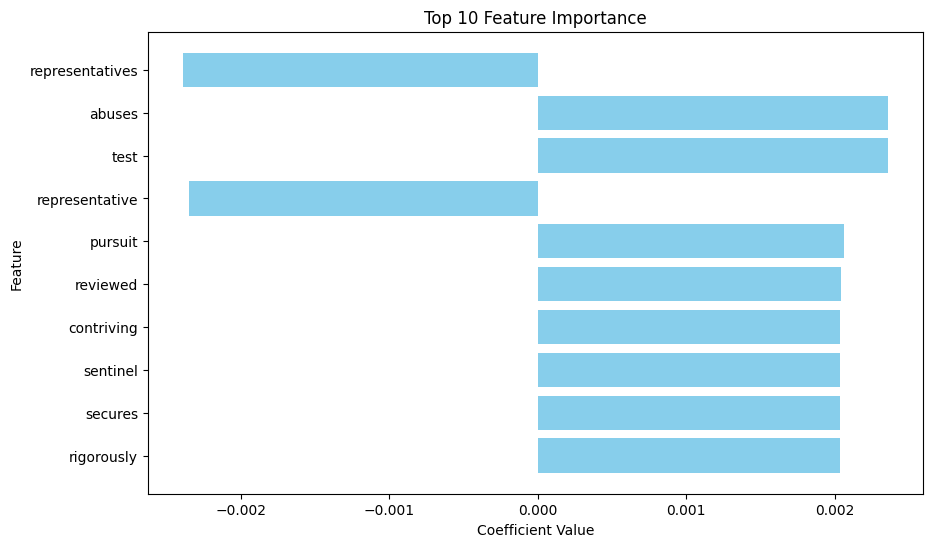

In [14]:
# Access feature importance (coefficients) for the linear SVC
feature_importance = classifier.coef_[0]  # For binary classification, use the first class

# Convert sparse matrix to dense array if necessary
if hasattr(feature_importance, "toarray"):
    feature_importance = feature_importance.toarray().flatten()

# Retrieve feature labels from the DTM's vectorizer
feature_labels = dtm.vectorizer.terms_list

# Sort features by importance
sorted_indices = np.argsort(np.abs(feature_importance))[::-1]  # Sort by absolute value
print("Top 10 Features by Importance:")
for idx in sorted_indices[:10]:
    print(f"Feature '{feature_labels[idx]}': Importance {feature_importance[idx]}")

# Optional: Plot top 10 feature importance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
top_10_indices = sorted_indices[:10]
top_10_features = [feature_labels[idx] for idx in top_10_indices]
top_10_importance = [feature_importance[idx] for idx in top_10_indices]
plt.barh(top_10_features, top_10_importance, color="skyblue")
plt.title("Top 10 Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.show()